In [1]:
# from google.colab import files
# uploaded = files.upload()

In [2]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%pip install category_encoders

# Setting display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.7/85.7 kB 4.1 MB/s eta 0:00:00


# Preprocessing
Since there is only training set in the donation.csv and outcome.csv, so we only take the results from the outcome.csv, and do not use donation.csv.

In [4]:
# Import packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Setting display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

In [5]:
# Read files
projects_df = pd.read_csv('/content/drive/MyDrive/KDD_Cup_2014_Data/projects.csv')
outcomes_df = pd.read_csv('/content/drive/MyDrive/KDD_Cup_2014_Data/outcomes.csv')

In [6]:
projects_df['date_posted']

,date_posted
0,2014-05-12
1,2014-05-12
2,2014-05-11
3,2014-05-11
4,2014-05-11
...,...
664093,2002-09-17
664094,2002-09-17
664095,2002-09-16
664096,2002-09-13


## Merge Outcome.csv and Projects.csv
Take samples after 2010

In [7]:
temp = pd.merge(projects_df[['projectid','date_posted']], outcomes_df[['projectid','is_exciting']], on='projectid', how='left')
temp['year'] = pd.DatetimeIndex(temp['date_posted']).year
index_2010_after = temp[temp['year'] >= 2010]

## Projects.csv

In [8]:
# Keep samples after 2010
projects_df = projects_df.merge(index_2010_after[['projectid']], on='projectid')
projects_df.shape

(484371, 35)

In [9]:
projects_df.head(1)

,projectid,teacher_acctid,schoolid,school_ncesid,school_latitude,school_longitude,school_city,school_state,school_zip,school_metro,school_district,school_county,school_charter,school_magnet,school_year_round,school_nlns,school_kipp,school_charter_ready_promise,teacher_prefix,teacher_teach_for_america,teacher_ny_teaching_fellow,primary_focus_subject,primary_focus_area,secondary_focus_subject,secondary_focus_area,resource_type,poverty_level,grade_level,fulfillment_labor_materials,total_price_excluding_optional_support,total_price_including_optional_support,students_reached,eligible_double_your_impact_match,eligible_almost_home_match,date_posted
0,316ed8fb3b81402ff6ac8f721bb31192,42d43fa6f37314365d08692e08680973,c0e6ce89b244764085691a1b8e28cb81,6.362701e+10,36.57634,-119.608713,Selma,CA,93662.0,NaN,Selma Unified Sch District,Fresno,f,f,f,f,f,f,Mrs.,f,f,Literature & Writing,Literacy & Language,College & Career Prep,Applied Learning,Books,highest poverty,Grades 6-8,30.0,555.81,653.89,32.0,f,f,2014-05-12


In [10]:
# Schoolid is school's unique identifier, we can drop school_ncesid
# And we have full data of latitude and longitude, we can drop school_zip
projects_df = projects_df.drop(columns=['school_zip', 'school_ncesid', 'total_price_excluding_optional_support'])

In [11]:
# Impute School_metro feature
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='most_frequent')
projects_df['school_metro'] = imputer.fit_transform(projects_df[['school_metro']]).ravel()  # Convert to 1D array

# Drop secondary_focus_subject, secondary_focus_area and school_district
projects_df = projects_df.drop(['secondary_focus_subject', 'secondary_focus_area', 'school_district'], axis=1)

In [12]:
# Impute missing values
projects_df[['primary_focus_subject', 'primary_focus_area', 'students_reached', 'grade_level']] = imputer.fit_transform(
    projects_df[['primary_focus_subject', 'primary_focus_area', 'students_reached', 'grade_level']])

In [13]:
projects_df['resource_type'] = projects_df['resource_type'].fillna('others')

In [14]:
projects_df.head()

,projectid,teacher_acctid,schoolid,school_latitude,school_longitude,school_city,school_state,school_metro,school_county,school_charter,school_magnet,school_year_round,school_nlns,school_kipp,school_charter_ready_promise,teacher_prefix,teacher_teach_for_america,teacher_ny_teaching_fellow,primary_focus_subject,primary_focus_area,resource_type,poverty_level,grade_level,fulfillment_labor_materials,total_price_including_optional_support,students_reached,eligible_double_your_impact_match,eligible_almost_home_match,date_posted
0,316ed8fb3b81402ff6ac8f721bb31192,42d43fa6f37314365d08692e08680973,c0e6ce89b244764085691a1b8e28cb81,36.576340,-119.608713,Selma,CA,urban,Fresno,f,f,f,f,f,f,Mrs.,f,f,Literature & Writing,Literacy & Language,Books,highest poverty,Grades 6-8,30.0,653.89,32.0,f,f,2014-05-12
1,90de744e368a7e4883223ca49318ae30,864eb466462bf704bf7a16a585ef296a,d711e47810900c96f26a5d0be30c446d,32.911179,-96.723640,Dallas,TX,urban,Dallas,f,f,f,f,f,f,Mrs.,f,f,Literacy,Literacy & Language,Books,highest poverty,Grades PreK-2,30.0,348.79,22.0,f,f,2014-05-12
2,32943bb1063267de6ed19fc0ceb4b9a7,37f85135259ece793213aca9d8765542,665c3613013ba0a66e3a2a26b89f1b68,45.166039,-122.414576,Colton,OR,rural,Clackamas,f,f,f,f,f,f,Mr.,f,f,Literacy,Literacy & Language,Technology,high poverty,Grades PreK-2,30.0,506.93,17.0,f,f,2014-05-11
3,bb18f409abda2f264d5acda8cab577a9,2133fc46f951f1e7d60645b0f9e48a6c,4f12c3fa0c1cce823c7ba1df57e90ccb,40.641727,-73.965655,Brooklyn,NY,urban,Kings (Brooklyn),f,t,f,f,f,f,Mr.,t,f,Social Sciences,History & Civics,Books,highest poverty,Grades 3-5,30.0,677.73,12.0,f,f,2014-05-11
4,24761b686e18e5eace634607acbcc19f,867ff478a63f5457eaf41049536c47cd,10179fd362d7b8cf0e89baa1ca3025bb,34.043939,-118.288371,Los Angeles,CA,urban,Los Angeles,f,f,f,f,f,f,Ms.,f,f,Mathematics,Math & Science,Other,highest poverty,Grades PreK-2,30.0,480.47,24.0,f,f,2014-05-11


## Feature matrix

In [21]:
data_labelIncluded = projects_df.merge(outcomes_df[['projectid', 'is_exciting']], on='projectid', how='inner')
print('feature matrix:')
data_labelIncluded.head(1)

feature matrix:


,projectid,teacher_acctid,schoolid,school_latitude,school_longitude,school_city,school_state,school_metro,school_county,school_charter,school_magnet,school_year_round,school_nlns,school_kipp,school_charter_ready_promise,teacher_prefix,teacher_teach_for_america,teacher_ny_teaching_fellow,primary_focus_subject,primary_focus_area,resource_type,poverty_level,grade_level,fulfillment_labor_materials,total_price_including_optional_support,students_reached,eligible_double_your_impact_match,eligible_almost_home_match,date_posted,is_exciting
0,62526d85d2a1818432d03d600969e99c,ebc7c90b6c92a069432e0714b8d93dfd,5aca9711ff0e4b37db48701f46f73036,41.972419,-88.174597,Bartlett,IL,suburban,Du Page,f,f,f,f,f,f,Mrs.,f,f,Special Needs,Special Needs,Other,moderate poverty,Grades 3-5,30.0,522.78,7.0,f,f,2013-12-31,f


## Merge data

In [15]:
projects_df.shape

(484371, 29)

In [20]:
clean_data = projects_df
data_labelIncluded = projects_df.merge(outcomes_df[['projectid', 'is_exciting']], on='projectid', how='inner')


In [ ]:
clean_data.shape

(484371, 29)

In [ ]:
clean_data.head()

,projectid,teacher_acctid,schoolid,school_latitude,school_longitude,school_city,school_state,school_metro,school_county,school_charter,school_magnet,school_year_round,school_nlns,school_kipp,school_charter_ready_promise,teacher_prefix,teacher_teach_for_america,teacher_ny_teaching_fellow,primary_focus_subject,primary_focus_area,resource_type,poverty_level,grade_level,fulfillment_labor_materials,total_price_including_optional_support,students_reached,eligible_double_your_impact_match,eligible_almost_home_match,date_posted
0,316ed8fb3b81402ff6ac8f721bb31192,42d43fa6f37314365d08692e08680973,c0e6ce89b244764085691a1b8e28cb81,36.576340,-119.608713,Selma,CA,urban,Fresno,f,f,f,f,f,f,Mrs.,f,f,Literature & Writing,Literacy & Language,Books,highest poverty,Grades 6-8,30.0,653.89,32.0,f,f,2014-05-12
1,90de744e368a7e4883223ca49318ae30,864eb466462bf704bf7a16a585ef296a,d711e47810900c96f26a5d0be30c446d,32.911179,-96.723640,Dallas,TX,urban,Dallas,f,f,f,f,f,f,Mrs.,f,f,Literacy,Literacy & Language,Books,highest poverty,Grades PreK-2,30.0,348.79,22.0,f,f,2014-05-12
2,32943bb1063267de6ed19fc0ceb4b9a7,37f85135259ece793213aca9d8765542,665c3613013ba0a66e3a2a26b89f1b68,45.166039,-122.414576,Colton,OR,rural,Clackamas,f,f,f,f,f,f,Mr.,f,f,Literacy,Literacy & Language,Technology,high poverty,Grades PreK-2,30.0,506.93,17.0,f,f,2014-05-11
3,bb18f409abda2f264d5acda8cab577a9,2133fc46f951f1e7d60645b0f9e48a6c,4f12c3fa0c1cce823c7ba1df57e90ccb,40.641727,-73.965655,Brooklyn,NY,urban,Kings (Brooklyn),f,t,f,f,f,f,Mr.,t,f,Social Sciences,History & Civics,Books,highest poverty,Grades 3-5,30.0,677.73,12.0,f,f,2014-05-11
4,24761b686e18e5eace634607acbcc19f,867ff478a63f5457eaf41049536c47cd,10179fd362d7b8cf0e89baa1ca3025bb,34.043939,-118.288371,Los Angeles,CA,urban,Los Angeles,f,f,f,f,f,f,Ms.,f,f,Mathematics,Math & Science,Other,highest poverty,Grades PreK-2,30.0,480.47,24.0,f,f,2014-05-11


In [ ]:
bool_columns = ['school_charter', 'school_magnet', 'school_year_round',
                 'school_nlns', 'school_kipp', 'school_charter_ready_promise',
                 'teacher_teach_for_america', 'teacher_ny_teaching_fellow',
                 'eligible_double_your_impact_match', 'eligible_almost_home_match']

for col in bool_columns:
    clean_data[col] = clean_data[col].map({'t': 1, 'f': 0})

In [ ]:
# Display the number of unique values in each column of clean_data
unique_counts = {col: clean_data[col].nunique() for col in clean_data.columns}
pd.Series(unique_counts).sort_values(ascending=False)

,0
projectid,484371
teacher_acctid,195149
total_price_including_optional_support,100352
schoolid,51207
school_longitude,49261
school_latitude,49242
school_city,8451
school_county,1669
date_posted,1592
students_reached,961


## Set train_X, train_y, *test_X*

In [ ]:
# Get training_set ids
training_ids = outcomes_df['projectid']
train_X = clean_data[clean_data['projectid'].isin(training_ids)]

In [ ]:
test_X = clean_data[~clean_data['projectid'].isin(training_ids)]

In [ ]:
# train_y preprocessing
train_y = outcomes_df.merge(train_X['projectid'], on='projectid')


In [ ]:
train_y['is_exciting'] = train_y['is_exciting'].map({'t': 1, 'f': 0})

In [ ]:
train_y.columns

Index(['projectid', 'is_exciting', 'at_least_1_teacher_referred_donor',
       'fully_funded', 'at_least_1_green_donation', 'great_chat',
       'three_or_more_non_teacher_referred_donors',
       'one_non_teacher_referred_donor_giving_100_plus',
       'donation_from_thoughtful_donor', 'great_messages_proportion',
       'teacher_referred_count', 'non_teacher_referred_count'],
      dtype='object')

In [ ]:
train_y = pd.DataFrame(train_y, columns=['projectid', 'is_exciting'])

In [ ]:
train_y.head()

,projectid,is_exciting
0,ffffac55ee02a49d1abc87ba6fc61135,0
1,ffff97ed93720407d70a2787475932b0,0
2,ffff2d9c769c8fb5335e949c615425eb,1
3,fffeebf4827d745aa36b17c2d38d1966,0
4,fffee68353ade53e7692b23098096683,0


In [ ]:
train_X.head()

,projectid,teacher_acctid,schoolid,school_latitude,school_longitude,school_city,school_state,school_metro,school_county,school_charter,school_magnet,school_year_round,school_nlns,school_kipp,school_charter_ready_promise,teacher_prefix,teacher_teach_for_america,teacher_ny_teaching_fellow,primary_focus_subject,primary_focus_area,resource_type,poverty_level,grade_level,fulfillment_labor_materials,total_price_including_optional_support,students_reached,eligible_double_your_impact_match,eligible_almost_home_match,date_posted
44772,62526d85d2a1818432d03d600969e99c,ebc7c90b6c92a069432e0714b8d93dfd,5aca9711ff0e4b37db48701f46f73036,41.972419,-88.174597,Bartlett,IL,suburban,Du Page,0,0,0,0,0,0,Mrs.,0,0,Special Needs,Special Needs,Other,moderate poverty,Grades 3-5,30.0,522.78,7.0,0,0,2013-12-31
44773,33d59ac771b80222ad63ef0f4ac47ade,de83b4c1f6428a15032c207c1d5e572a,d91a805b213bf74ae77b94e0de2b73ad,43.501154,-112.056780,Idaho Falls,ID,urban,Bonneville,0,0,0,0,0,0,Mrs.,0,0,Mathematics,Math & Science,Supplies,high poverty,Grades 3-5,30.0,274.40,30.0,0,0,2013-12-31
44774,1a3aaeffc56dd2a421e37d8298024c0a,f4c9ed095b85458dcf858e25f203af00,9310d3eb447a4e46bc5fc31ed007ceac,42.888244,-71.320224,Derry,NH,suburban,Rockingham,0,0,0,0,0,0,Mrs.,0,0,Environmental Science,Math & Science,Technology,moderate poverty,Grades 6-8,30.0,335.40,230.0,0,0,2013-12-31
44775,33aa19ee4da4c5adf47d0dfb84fab5ef,17768031eb40de8d4497dbb54df48742,9ac70da58322783f82152eecc140a812,37.476158,-77.488397,Richmond,VA,urban,Richmond City,0,0,0,0,0,0,Ms.,0,0,Literacy,Literacy & Language,Other,highest poverty,Grades PreK-2,30.0,274.05,18.0,0,0,2013-12-31
44776,e31c0ea8b68f404699dfb0d39e9bc99b,0f1bc5b4700fd33383be104442660178,cb9f688cf59e3ee22a087d616ca8f5d7,41.952851,-87.650233,Chicago,IL,urban,Cook,0,1,0,0,0,0,Mr.,0,0,Environmental Science,Math & Science,Supplies,highest poverty,Grades 6-8,30.0,604.01,70.0,1,0,2013-12-31


### train_test_split

In [ ]:
from sklearn.model_selection import train_test_split

# Set projectid as index
train_X.set_index('projectid', inplace=True)
train_y.set_index('projectid', inplace=True)

# Ensure consistent indices
common_ids = train_X.index.intersection(train_y.index)
train_X = train_X.loc[common_ids]
train_y = train_y.loc[common_ids]

# Convert date_posted to datetime format
train_X['date_posted'] = pd.to_datetime(train_X['date_posted'])

# Sort data by date
train_X_sorted = train_X.sort_values('date_posted')
train_y_sorted = train_y.loc[train_X_sorted.index]

# Find 80% time point as split point for train and validation sets
split_date = train_X_sorted['date_posted'].quantile(0.8)
print(f"Split date: {split_date} - 80% of data is before this date")

# Split train and validation sets based on date
X_train_sub = train_X_sorted[train_X_sorted['date_posted'] <= split_date]
X_val = train_X_sorted[train_X_sorted['date_posted'] > split_date]

y_train_sub = train_y_sorted.loc[X_train_sub.index]
y_val = train_y_sorted.loc[X_val.index]

print(f"Training set size: {X_train_sub.shape[0]}")
print(f"Validation set size: {X_val.shape[0]}")
print(f"Positive sample ratio in training set: {y_train_sub['is_exciting'].mean()*100:.2f}%")
print(f"Positive sample ratio in validation set: {y_val['is_exciting'].mean()*100:.2f}%")

Split date: 2013-07-01 00:00:00 - 80% of data is before this date
Training set size: 351683
Validation set size: 87916
Positive sample ratio in training set: 7.20%
Positive sample ratio in validation set: 12.97%


### Encoding
Use OneHotEncoding to handle `resource_type`, `primary_focus_area`, `grade_level`,
    `poverty_level`, `teacher_prefix`, `fulfillment_labor_materials`, `school_metro` which have less categories

Use TargetEncoding handling `school_state`, `primary_focus_subject`, `school_city`, `school_county` which have many categories


In [ ]:
# Import necessary libraries for encoding
from sklearn.preprocessing import OneHotEncoder, LabelEncoder

# Important: Only fit on training data to prevent data leakage
df = X_train_sub.copy()

# OneHotEncoding - Only fit on training set
onehot_columns = [
    'resource_type', 'primary_focus_area', 'grade_level',
    'poverty_level', 'teacher_prefix', 'fulfillment_labor_materials', 'school_metro'
]

encoder = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')

# Only fit_transform on training set
encoded_array = encoder.fit_transform(df[onehot_columns])
feature_names = encoder.get_feature_names_out(onehot_columns)
encoded_df = pd.DataFrame(encoded_array, columns=feature_names, index=df.index)
df_train_encoded = pd.concat([df.drop(onehot_columns, axis=1), encoded_df], axis=1)

# Target encoding - Only fit on training set
from category_encoders import TargetEncoder
target_columns = ['school_state', 'primary_focus_subject', 'school_city', 'school_county']
target_encoder = TargetEncoder(cols=target_columns)

# Only fit_transform on training set
df_train_encoded = target_encoder.fit_transform(df_train_encoded, y_train_sub['is_exciting'])

# For validation set, only transform without fitting
val_encoded_array = encoder.transform(X_val[onehot_columns])
val_encoded_df = pd.DataFrame(val_encoded_array, columns=feature_names, index=X_val.index)
df_val_encoded = pd.concat([X_val.drop(onehot_columns, axis=1), val_encoded_df], axis=1)
df_val_encoded = target_encoder.transform(df_val_encoded)


# EDA


Top features correlated with is_exciting:
is_exciting                               1.000000
teacher_teach_for_america                 0.070562
fulfillment_labor_materials               0.055076
school_charter                            0.044075
school_latitude                           0.039652
school_longitude                          0.023690
school_kipp                               0.020167
school_nlns                               0.018954
teacher_ny_teaching_fellow                0.009394
school_magnet                             0.005149
school_charter_ready_promise              0.003951
school_year_round                        -0.005854
total_price_including_optional_support   -0.010105
eligible_almost_home_match               -0.028927
eligible_double_your_impact_match        -0.031965
Name: is_exciting, dtype: float64

Features least correlated with is_exciting:
school_charter_ready_promise              0.003951
school_year_round                        -0.005854
total_price

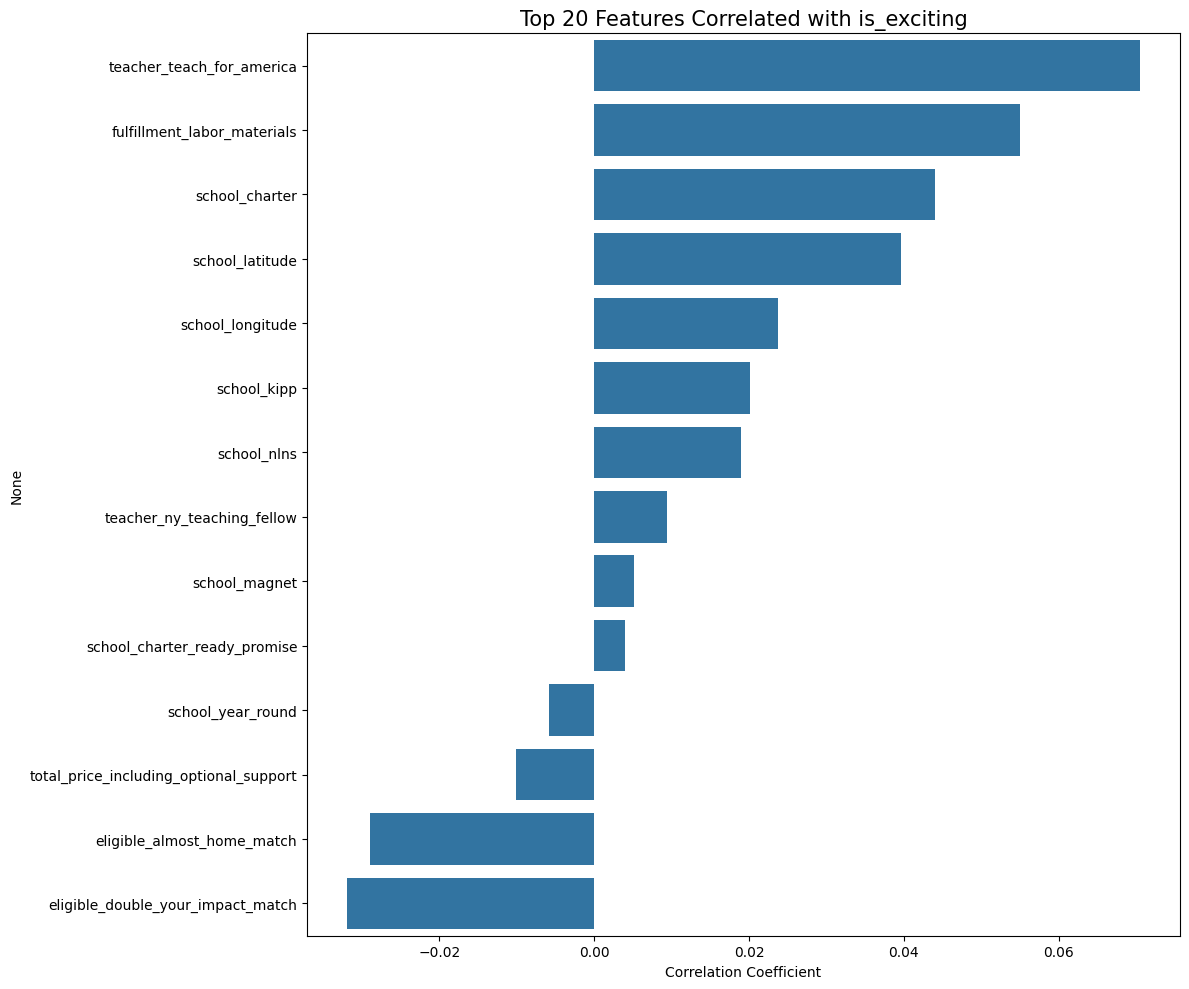

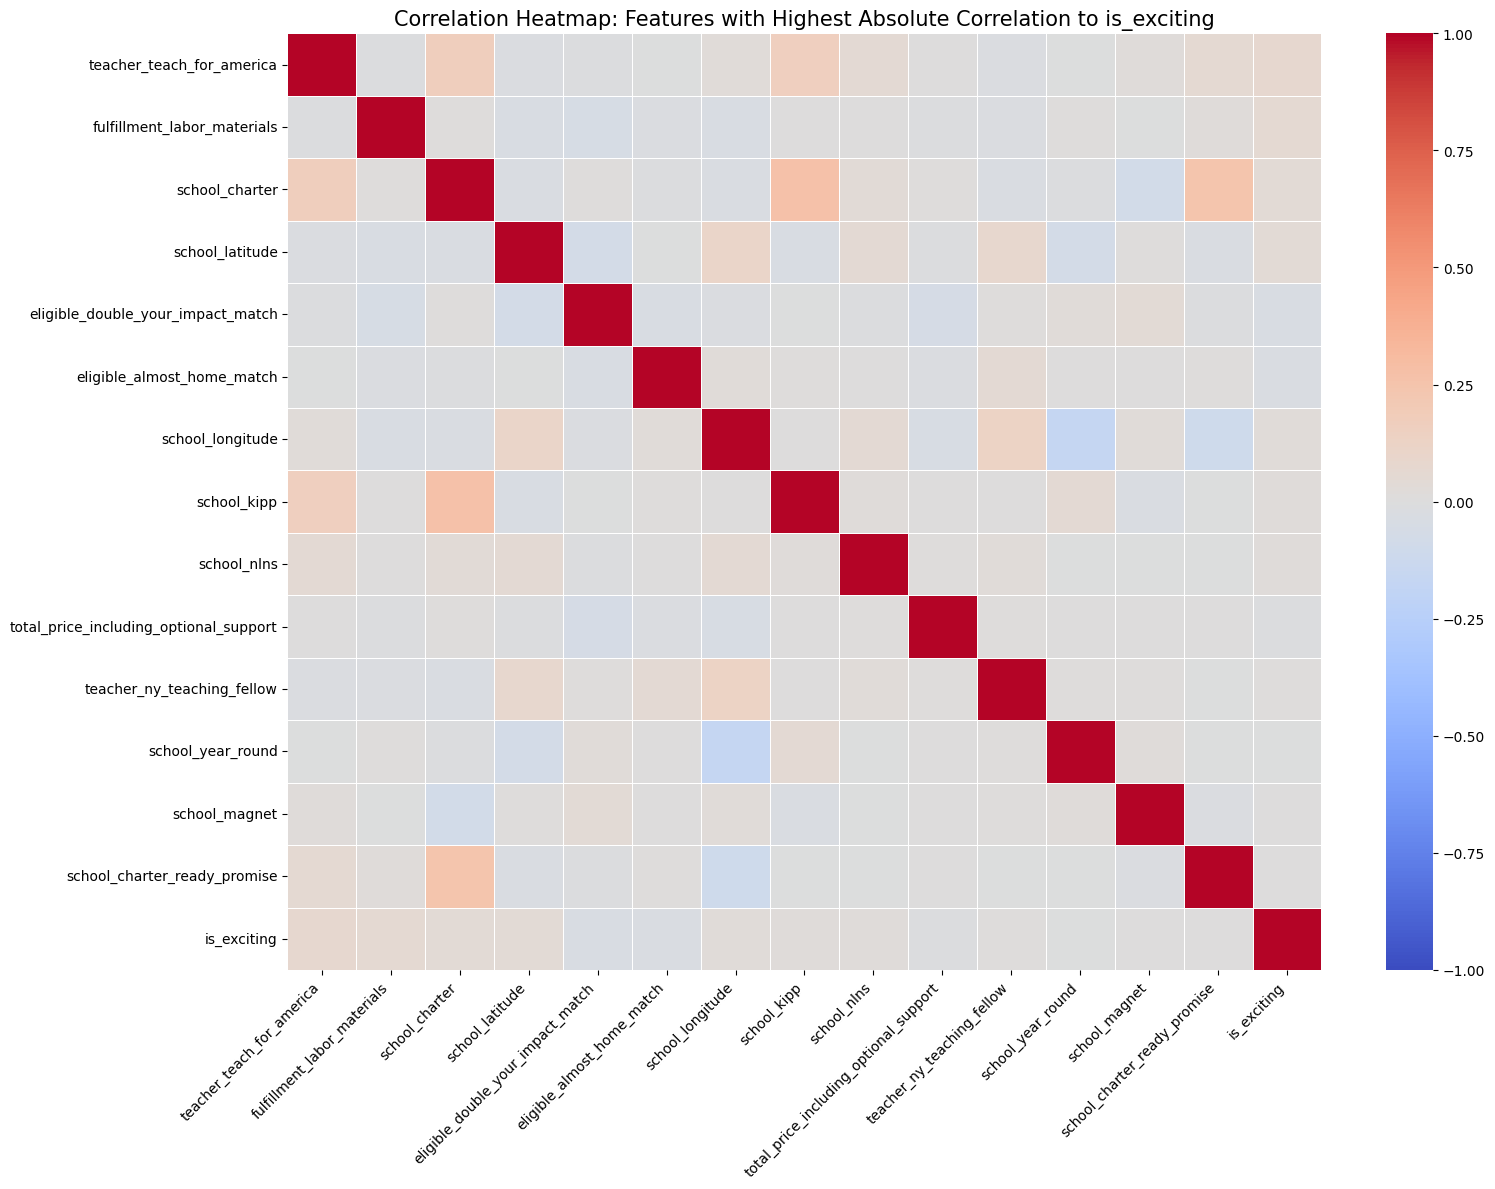

In [ ]:
import seaborn as sns

combined_data = train_X.copy()
combined_data['is_exciting'] = train_y['is_exciting']

# Select numeric columns
numeric_columns = combined_data.select_dtypes(include=['int64', 'float64']).columns.tolist()
numeric_data = combined_data[numeric_columns]

# Compute correlation
if 'is_exciting' in numeric_columns:
    correlation_with_target = numeric_data.corr()['is_exciting'].sort_values(ascending=False)

    print("\nTop features correlated with is_exciting:")
    print(correlation_with_target.head(15))
    print("\nFeatures least correlated with is_exciting:")
    print(correlation_with_target.tail(5))

    # Visualization
    plt.figure(figsize=(12, 10))
    top_features = correlation_with_target[1:21]  # Take the top 20 features
    sns.barplot(x=top_features.values, y=top_features.index)
    plt.title('Top 20 Features Correlated with is_exciting', fontsize=15)
    plt.xlabel('Correlation Coefficient')
    plt.tight_layout()
    plt.savefig('is_exciting_correlation.png')
    plt.show()


    # Take top30
    abs_corr = correlation_with_target.abs().sort_values(ascending=False)
    top_abs_features = list(abs_corr.iloc[1:31].index)
    top_abs_features.append('is_exciting')

    # Plot heatmap
    plt.figure(figsize=(16, 12))
    abs_corr_matrix = numeric_data[top_abs_features].corr()
    sns.heatmap(abs_corr_matrix, annot=False, cmap='coolwarm',
                linewidths=0.5, vmin=-1, vmax=1)
    plt.title('Correlation Heatmap: Features with Highest Absolute Correlation to is_exciting', fontsize=15)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig('is_exciting_abs_heatmap.png')
    plt.show()

### Handling outliers

In [ ]:
# Note: Use df_train_encoded instead of undefined df_encoded variable
numeric_columns = df_train_encoded.select_dtypes(include=['int', 'float']).columns

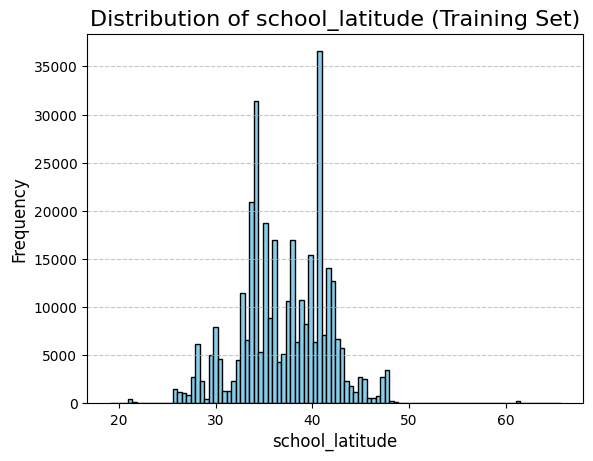

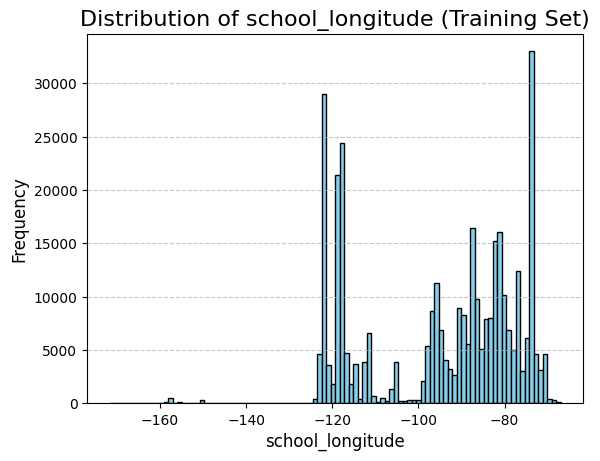

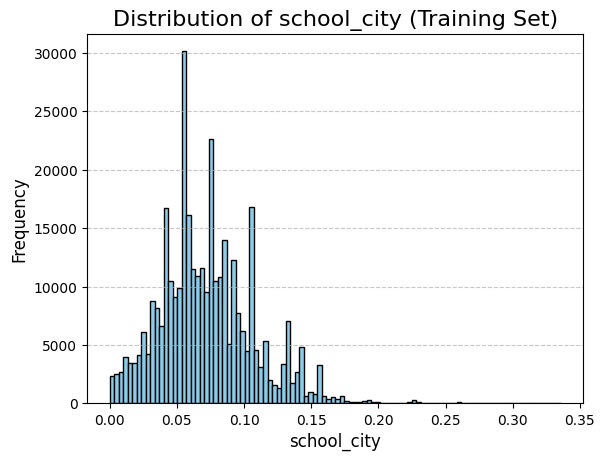

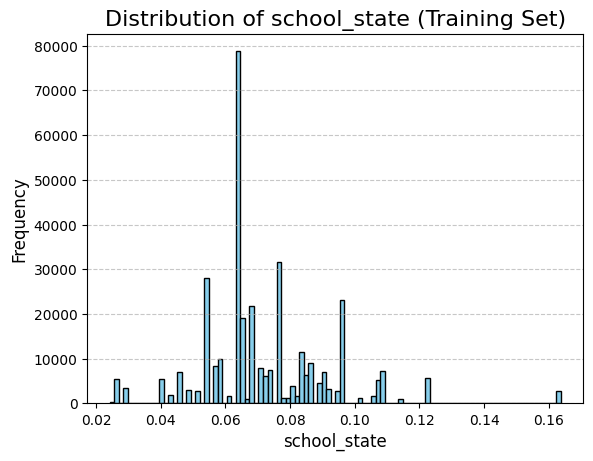

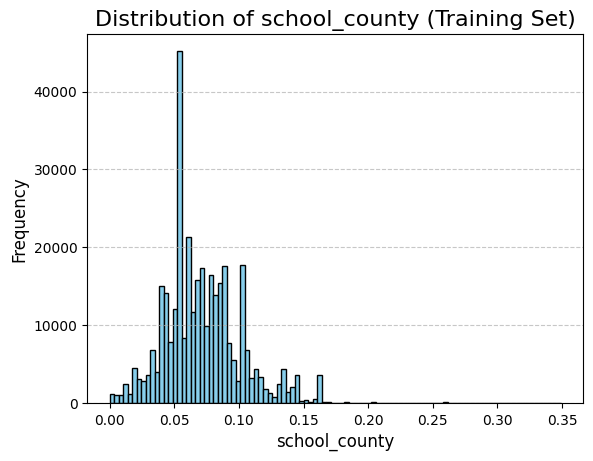

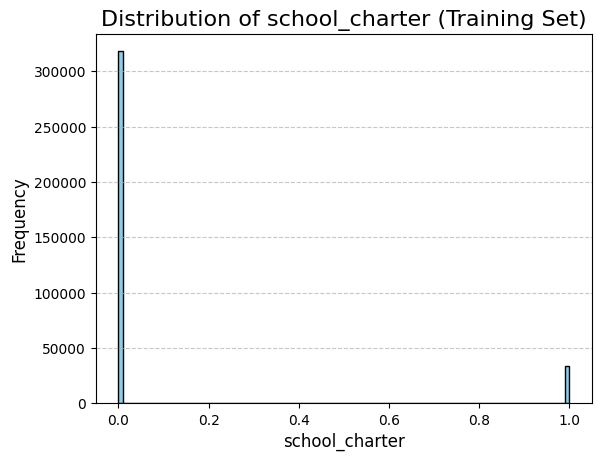

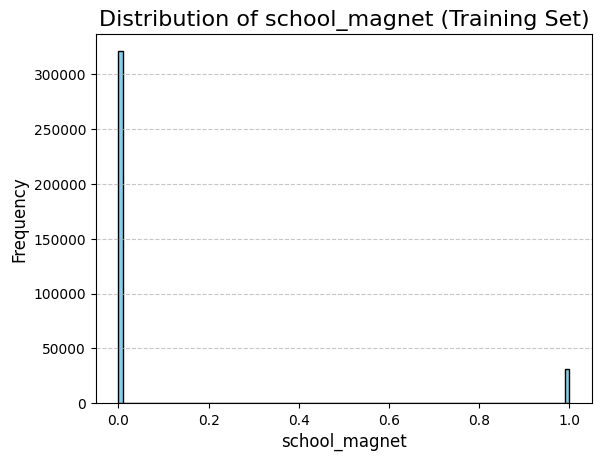

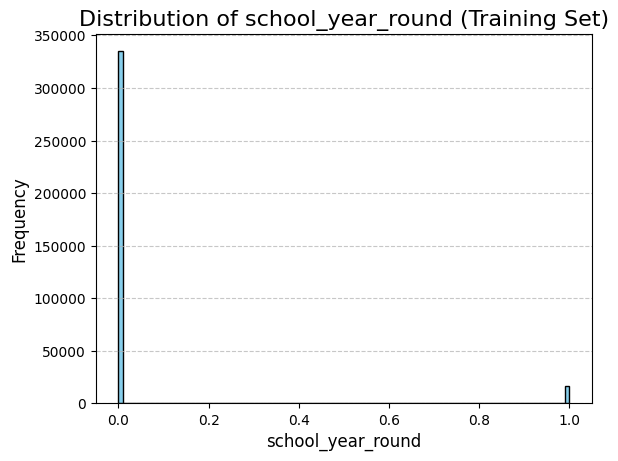

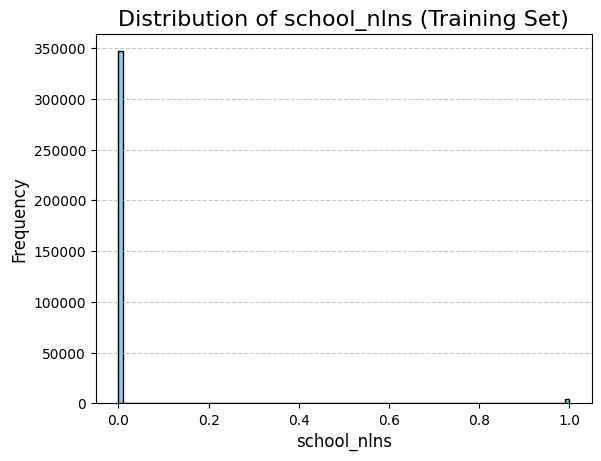

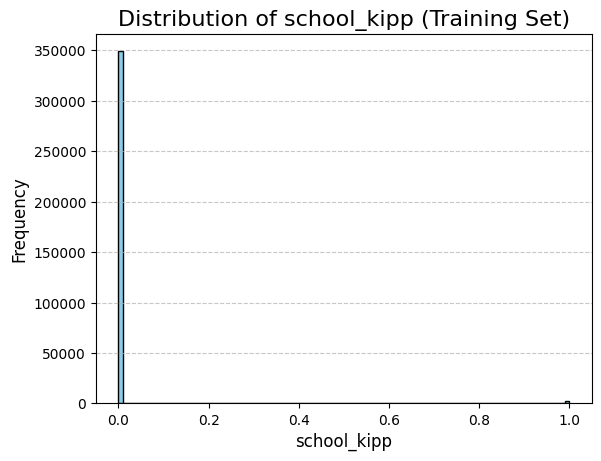

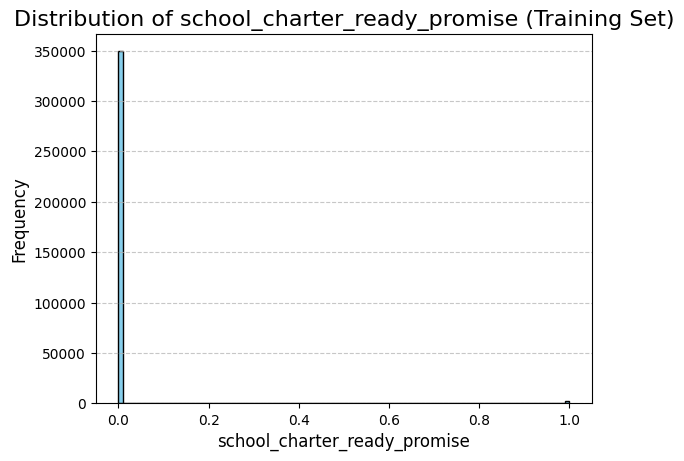

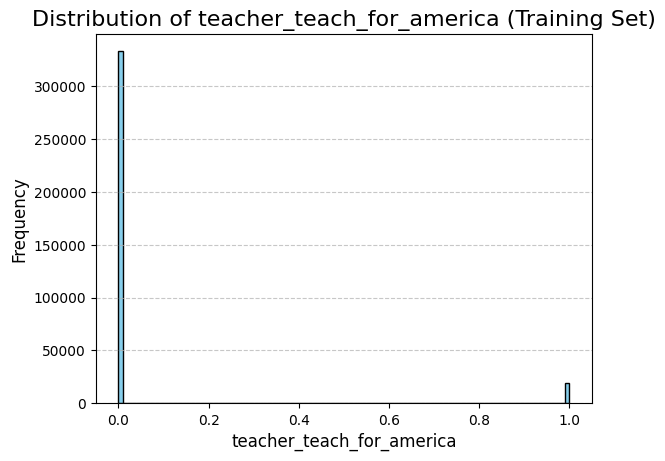

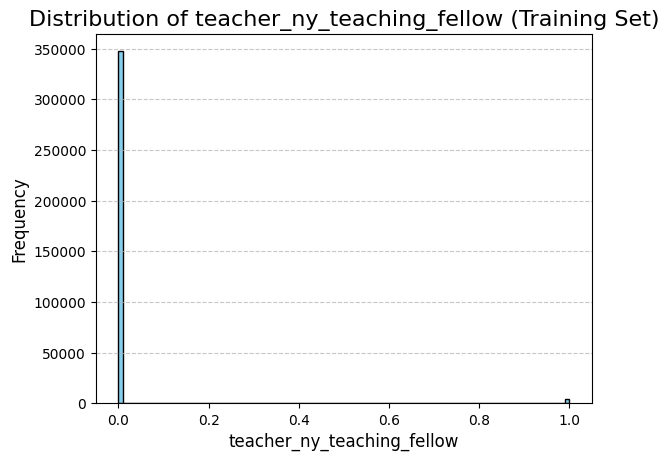

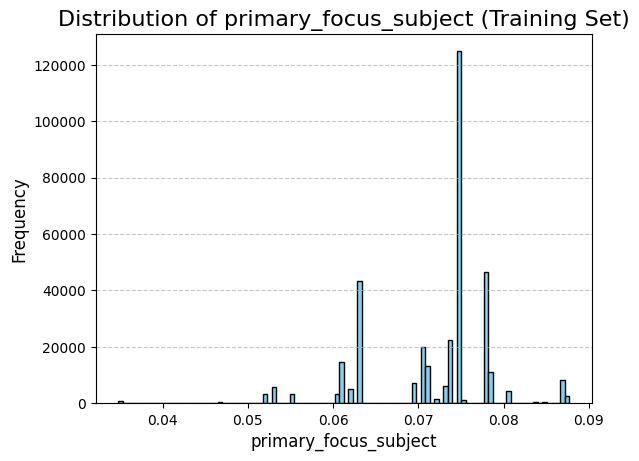

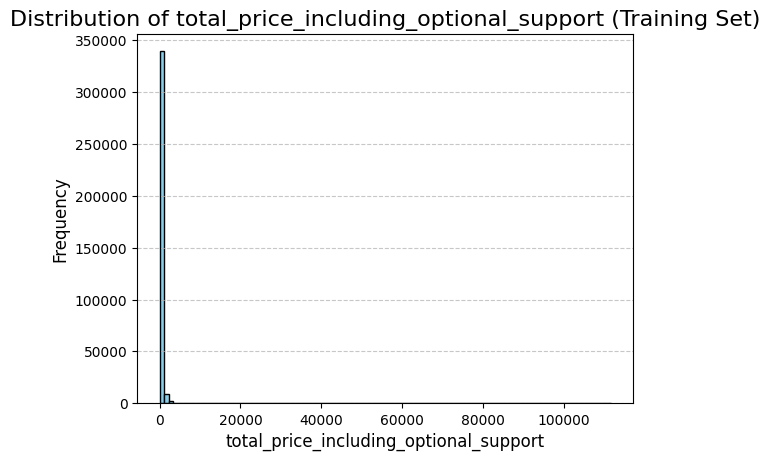

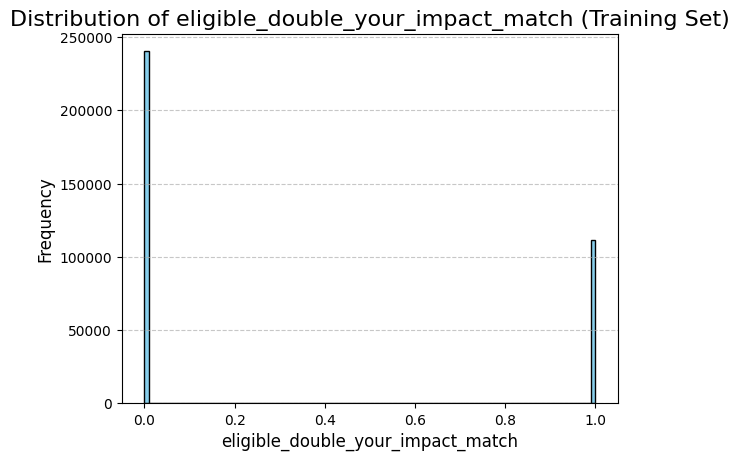

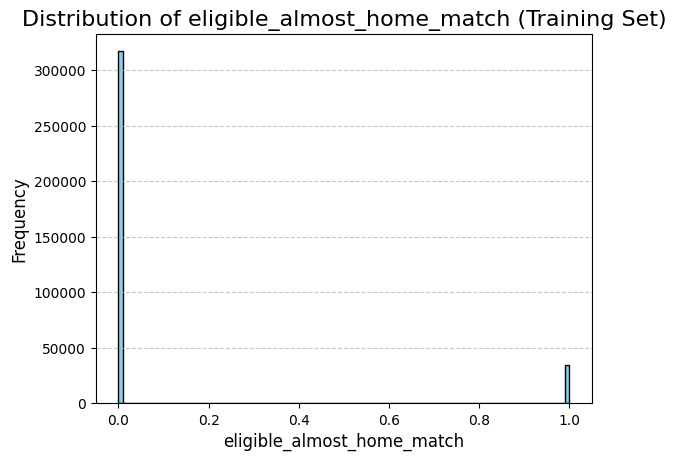

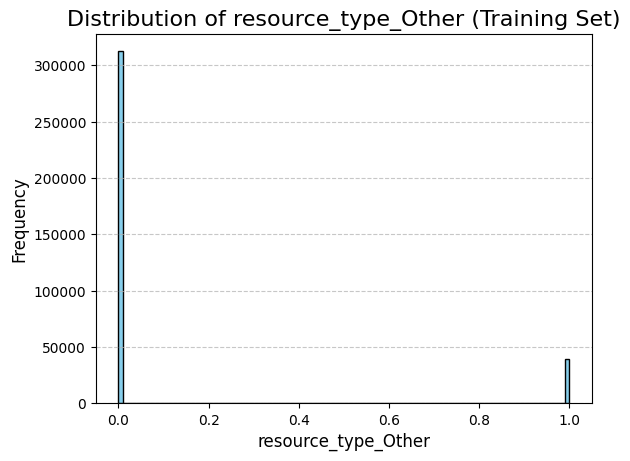

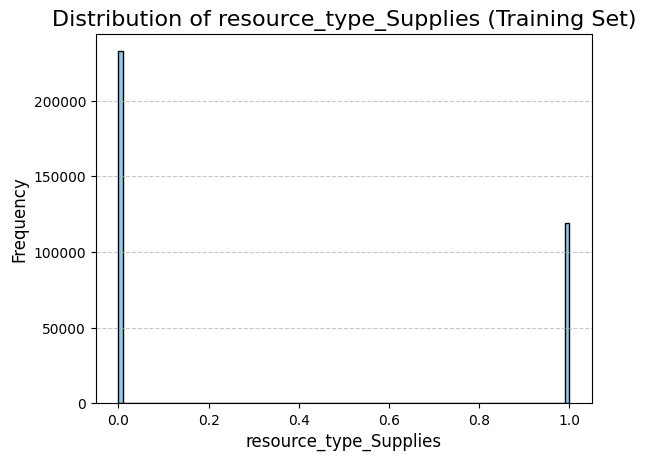

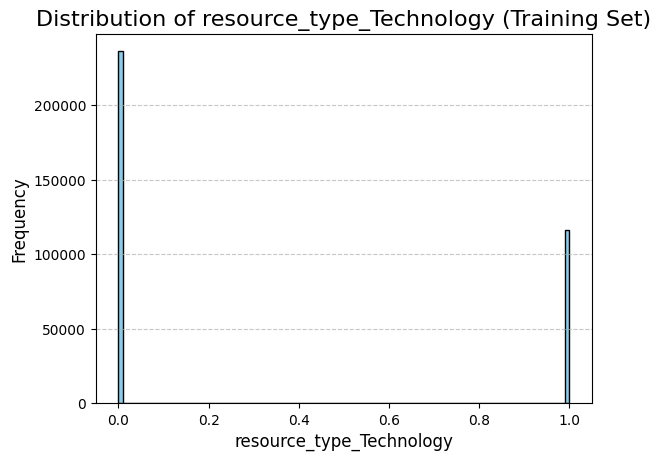

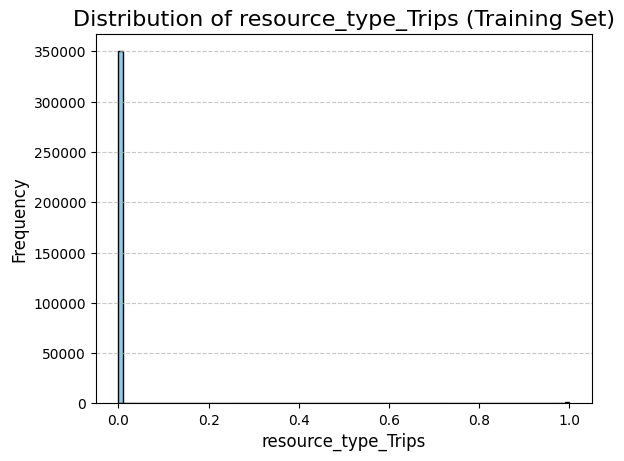

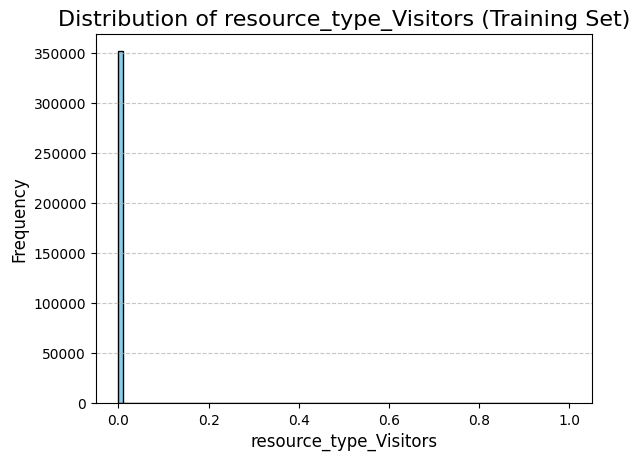

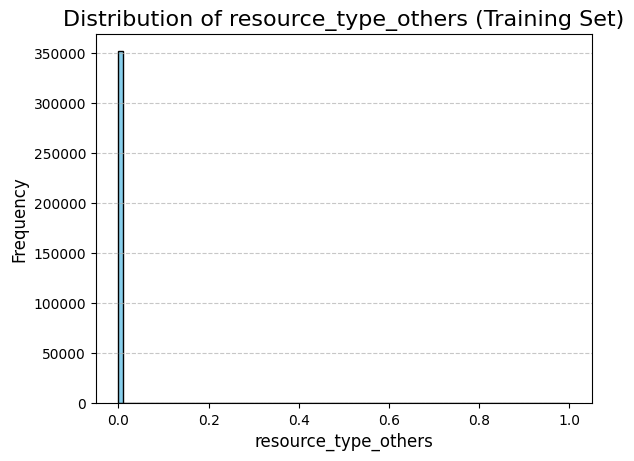

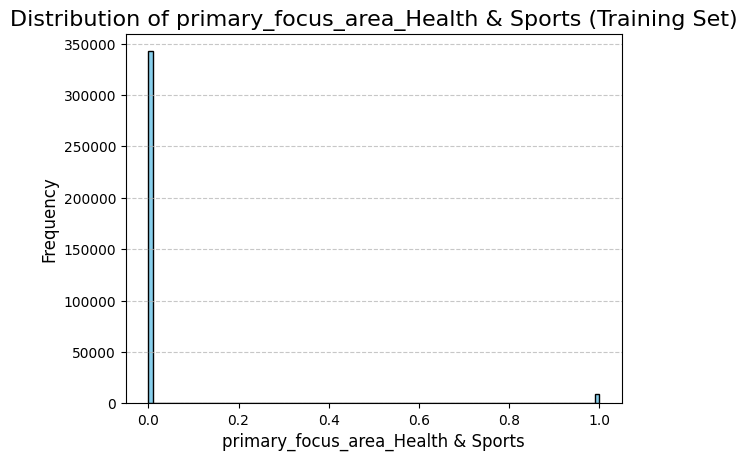

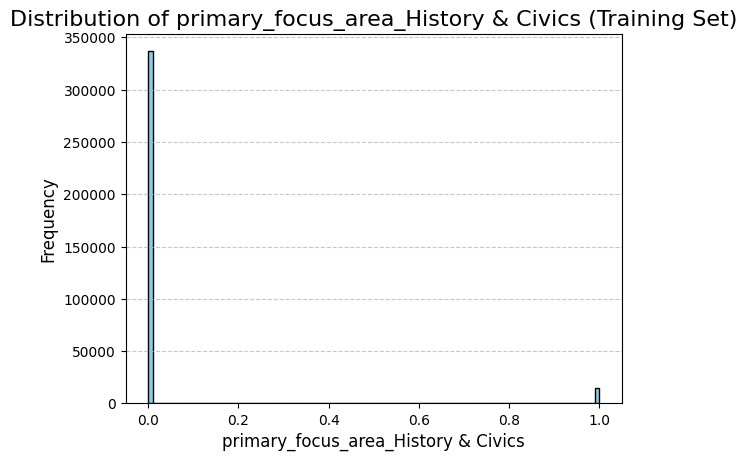

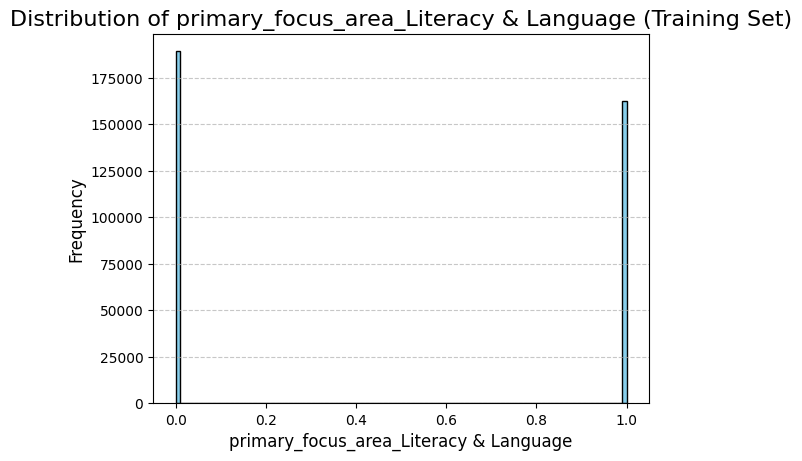

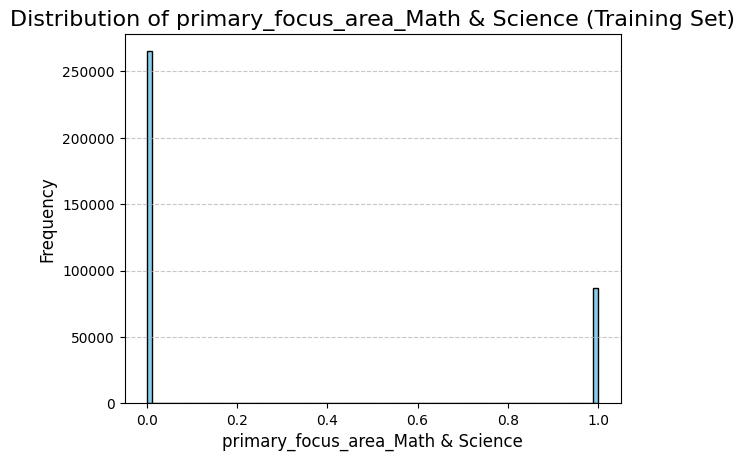

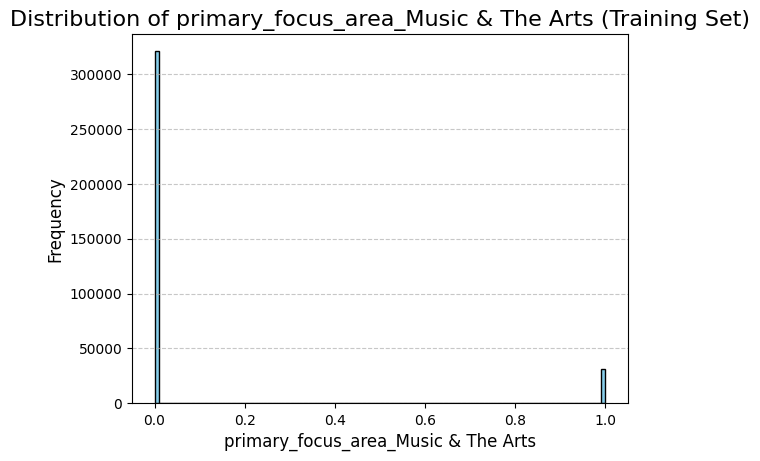

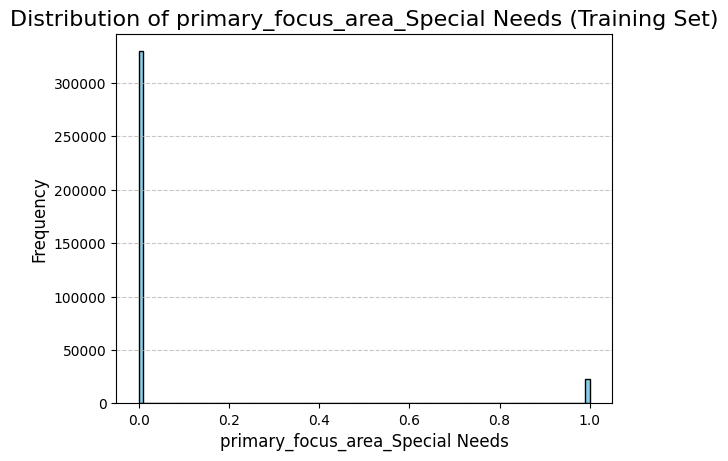

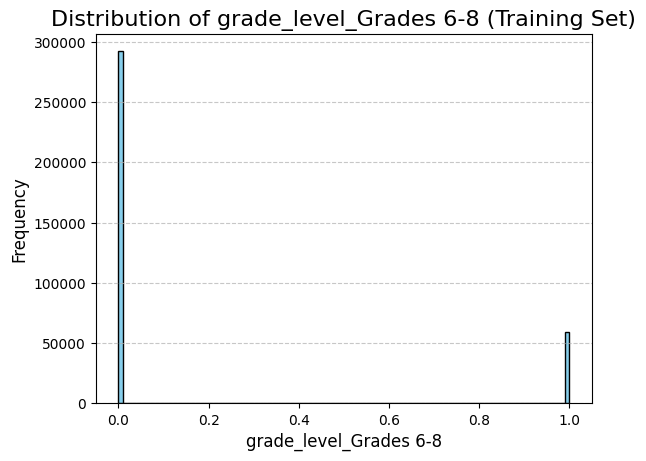

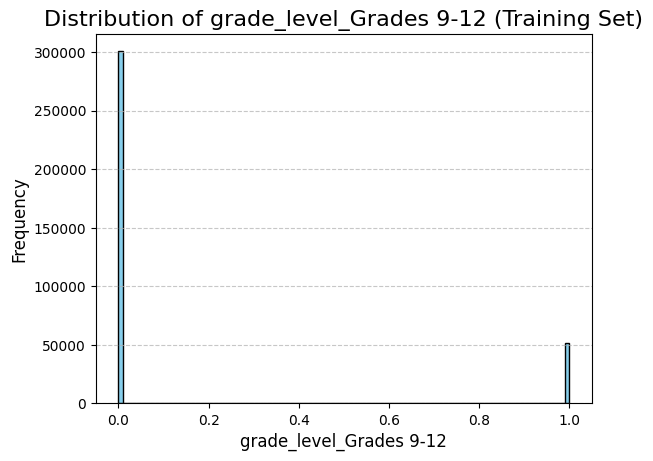

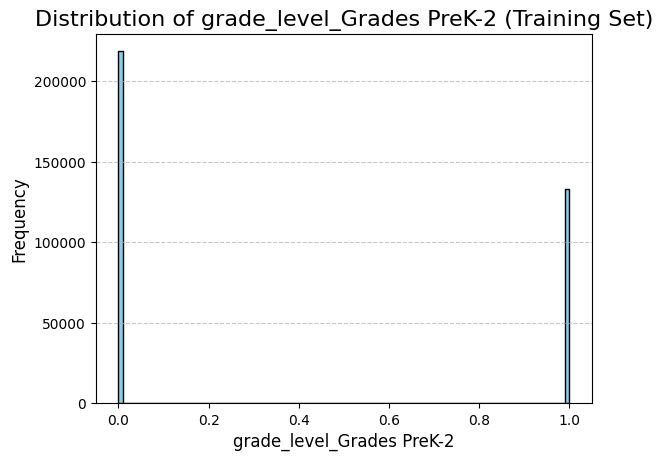

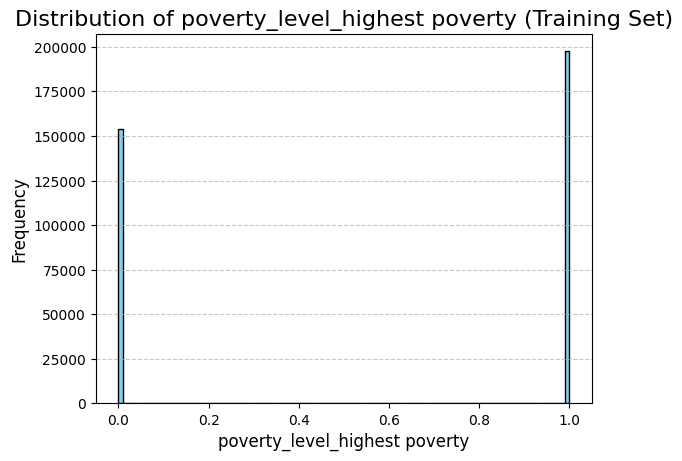

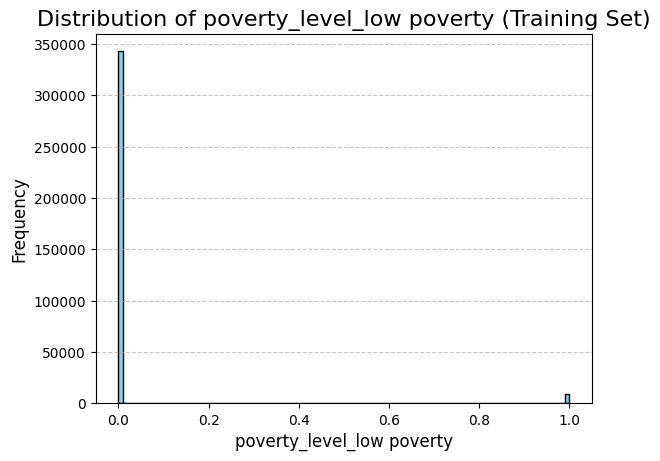

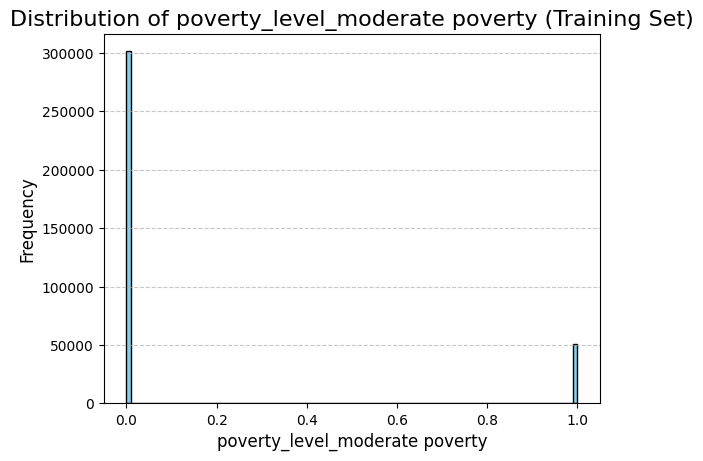

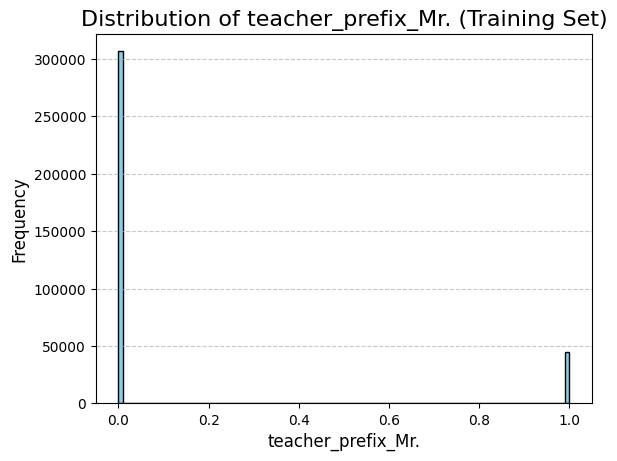

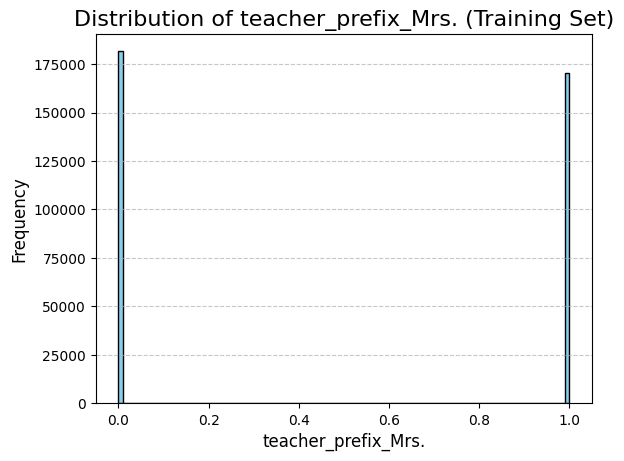

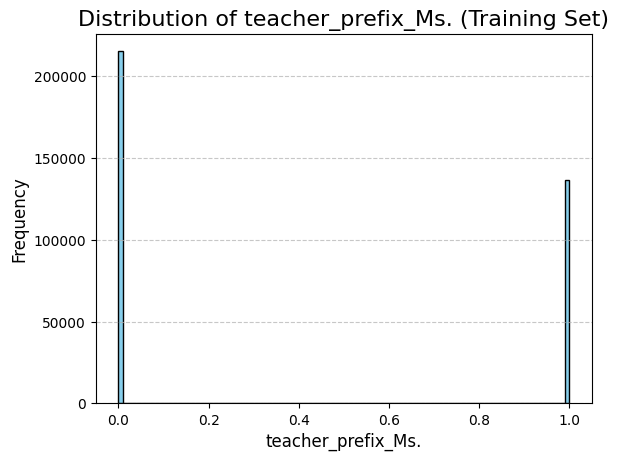

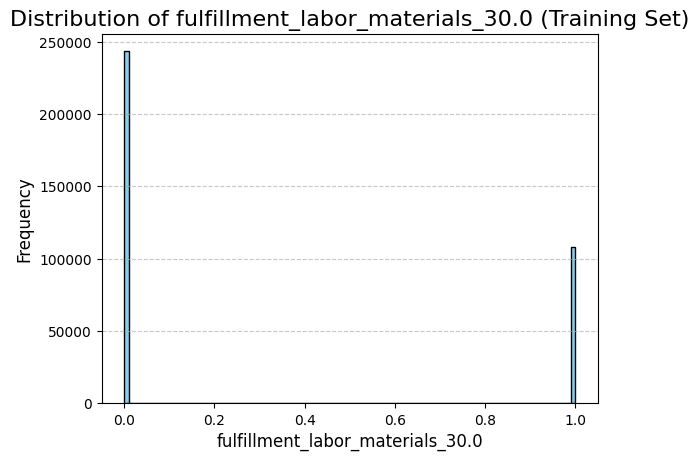

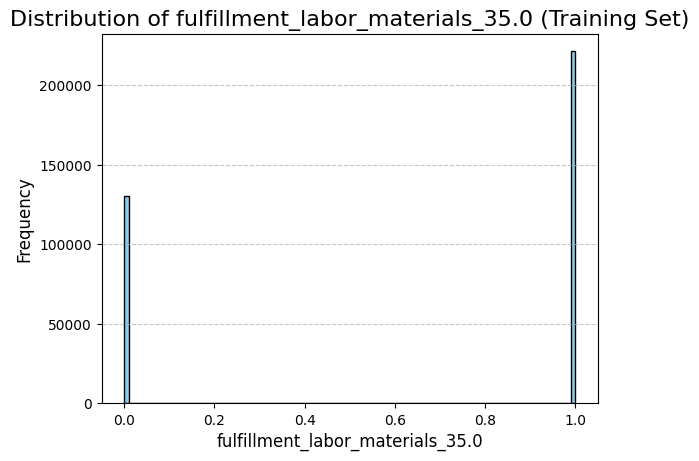

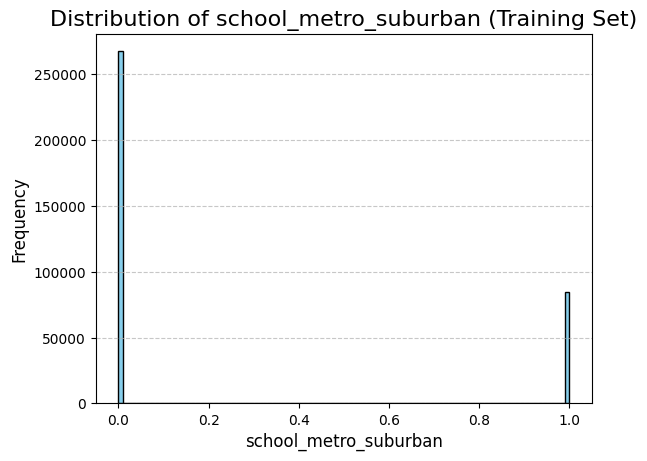

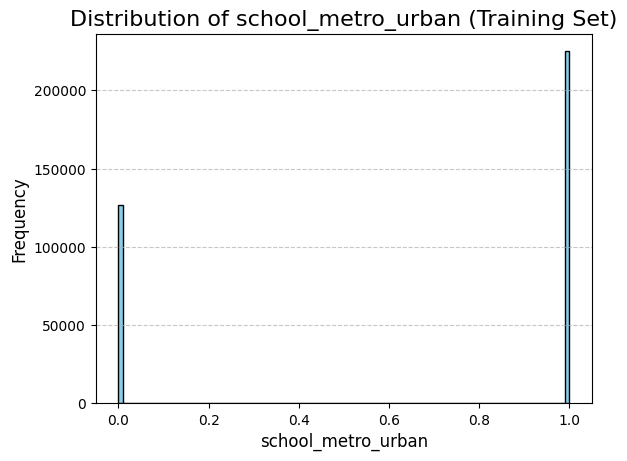

In [ ]:
# Visualize training set data
for col in numeric_columns:
    if col in df_train_encoded.columns:
        df_train_encoded[col].plot(kind='hist', bins=100, color='skyblue', edgecolor='black')
        plt.title(f'Distribution of {col} (Training Set)', fontsize=16)
        plt.xlabel(col, fontsize=12)
        plt.ylabel('Frequency', fontsize=12)
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.show()

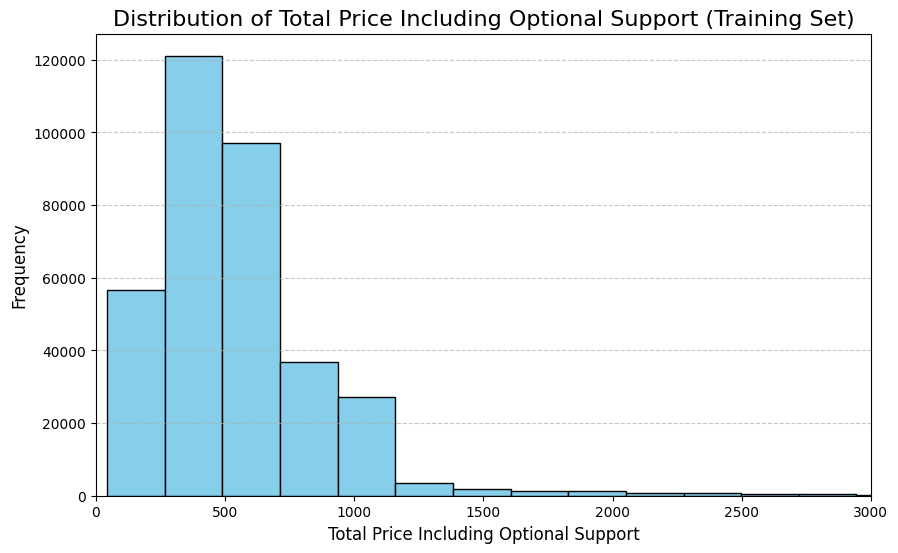

In [ ]:
# Plot histogram for total_price_including_optional_support in the training set
plt.figure(figsize=(10, 6))
if 'total_price_including_optional_support' in df_train_encoded.columns:
    df_train_encoded['total_price_including_optional_support'].plot(kind='hist', bins=500, color='skyblue', edgecolor='black')
    plt.xlim(0, 3000)
    plt.title('Distribution of Total Price Including Optional Support (Training Set)', fontsize=16)
    plt.xlabel('Total Price Including Optional Support', fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

### Remove Outliers
Only process outliers in the training set to avoid data leakage

In [ ]:
# 1. Identify all numeric features
numeric_cols = df_train_encoded.select_dtypes(include=['number']).columns

# 2. Calculate IQR bounds for each numeric feature
bounds = {}
for col in numeric_cols:
    Q1 = df_train_encoded[col].quantile(0.25)
    Q3 = df_train_encoded[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    bounds[col] = (lower, upper)

# 3. Training set: remove any row where any numeric column is an outlier
outlier_mask = np.zeros(df_train_encoded.shape[0], dtype=bool)
for col in numeric_cols:
    lower, upper = bounds[col]
    outlier_mask |= (df_train_encoded[col] < lower) | (df_train_encoded[col] > upper)

print(f"Total number of outlier rows in training set: {outlier_mask.sum()} (Percentage: {outlier_mask.mean():.2%})")
df_train_encoded_clean = df_train_encoded[~outlier_mask].copy()
y_train_clean = y_train_sub[~outlier_mask].copy()
print(f"Number of samples in training set after cleaning: {df_train_encoded_clean.shape[0]}")

# 4. Validation set: clip all numeric features to their IQR bounds
df_val_encoded_clean = df_val_encoded.copy()
for col in numeric_cols:
    if col in df_val_encoded_clean.columns:
        lower, upper = bounds[col]
        df_val_encoded_clean[col] = df_val_encoded_clean[col].clip(lower=lower, upper=upper)


Total number of outlier rows in training set: 310376 (Percentage: 88.25%)
Number of samples in training set after cleaning: 41307


# Grid Search


## K nearest Neighbor classifier (baseline)

  1.   doing StandardScaler
  2.   applying SMOTE(imbalanced data)
  3.   model fit



In [ ]:
columns_to_drop = [
    'projectid', 'teacher_acctid_x', 'schoolid', 'students_reached',
    'date_posted', 'teacher_acctid_y', 'title',
    'short_description', 'need_statement', 'essay'
]

# Use cleaned dataframes
X_train = df_train_encoded_clean.drop(columns=[col for col in columns_to_drop if col in df_train_encoded_clean.columns])
X_val = df_val_encoded_clean.drop(columns=[col for col in columns_to_drop if col in df_val_encoded_clean.columns])

# delete non_numerical column
non_numeric_cols = X_train.select_dtypes(exclude=['int64', 'float64', 'bool']).columns.tolist()
if non_numeric_cols:
    X_train = X_train.drop(columns=non_numeric_cols)
    X_val = X_val.drop(columns=[col for col in non_numeric_cols if col in X_val.columns])

# 2. Apply standardization
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# 3. Apply SMOTE to Training set
%pip install imbalanced-learn
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train_clean)

# 4. Basic evaluation using KNN
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, roc_auc_score

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_resampled, y_train_resampled)

# Evaluate on validation set

y_val_pred = knn.predict(X_val_scaled)
accuracy = accuracy_score(y_val, y_val_pred)
print(f"Basic KNN model accuracy on validation set: {accuracy * 100:.2f}%")

y_val_pred_proba = knn.predict_proba(X_val_scaled)[:, 1]
roc_auc = roc_auc_score(y_val, y_val_pred_proba)
print(f"ROC AUC Score: {roc_auc:.4f}")

/usr/local/lib/python3.11/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


Basic KNN model accuracy on validation set: 72.92%
ROC AUC Score: 0.5415


## Grid Search

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report
from sklearn.neighbors import KNeighborsClassifier
import numpy as np

# Print the shape of feature set and label set
print(f"Number of feature samples: {X_train_scaled.shape[0]}")
print(f"Number of label samples: {len(y_train_sub)}")

# Since the feature set is a NumPy array without an index, we need to use different methods to align the data
# Method 1: If features and labels are arranged in the same order during generation, just take the same length
min_samples = min(X_train_scaled.shape[0], len(y_train_sub))
X_train_aligned = X_train_scaled[:min_samples]
y_train_aligned = y_train_sub.iloc[:min_samples] if hasattr(y_train_sub, 'iloc') else y_train_sub[:min_samples]

print(f"Number of feature samples after alignment: {X_train_aligned.shape[0]}")
print(f"Number of label samples after alignment: {len(y_train_aligned)}")

# Check if there are still NaN values
print(f"Number of NaN values in feature set: {np.isnan(X_train_aligned).sum()}")
if hasattr(y_train_aligned, 'isna'):
    print(f"Number of NaN values in label set: {y_train_aligned.isna().sum()}")
else:
    print(f"Number of NaN values in label set: {np.isnan(y_train_aligned).sum()}")

# Define hyperparameter grid
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 15],  # Try different k values
    'weights': ['uniform', 'distance'],  # Weight function used in prediction
    'metric': ['euclidean', 'manhattan', 'minkowski']  # Distance metrics
}

# Execute grid search using 5-fold cross-validation on the training set
grid_search = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,  # Use all available processors
    verbose=2
)

# Fit the model on the training data
print("Starting grid search...")
grid_search.fit(X_train_aligned, y_train_aligned)

# Output the best parameters and best score
print("Best parameters:", grid_search.best_params_)
print("Best cross-validation accuracy:", grid_search.best_score_)

# Similarly ensure the validation set lengths are consistent
min_val_samples = min(X_val_scaled.shape[0], len(y_val))
X_val_aligned = X_val_scaled[:min_val_samples]
y_val_aligned = y_val.iloc[:min_val_samples] if hasattr(y_val, 'iloc') else y_val[:min_val_samples]

# Evaluate on the validation set using the best model
best_model = grid_search.best_estimator_
y_val_pred = best_model.predict(X_val_aligned)
val_accuracy = accuracy_score(y_val_aligned, y_val_pred)
print(f"Validation set accuracy: {val_accuracy * 100:.2f}%")

# Print detailed classification report
print("Validation set classification report:")
print(classification_report(y_val_aligned, y_val_pred))

Number of feature samples: 41307
Number of label samples: 351683
Number of feature samples after alignment: 41307
Number of label samples after alignment: 41307
Number of NaN values in feature set: 0
Number of NaN values in label set: is_exciting    0
dtype: int64
Starting grid search...
Fitting 5 folds for each of 36 candidates, totalling 180 fits


/usr/local/lib/python3.11/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


Best parameters: {'metric': 'euclidean', 'n_neighbors': 9, 'weights': 'uniform'}
Best cross-validation accuracy: 0.9860798411401964
Validation set accuracy: 87.03%
Validation set classification report:
              precision    recall  f1-score   support

           0       0.87      1.00      0.93     76513
           1       0.00      0.00      0.00     11403

    accuracy                           0.87     87916
   macro avg       0.44      0.50      0.47     87916
weighted avg       0.76      0.87      0.81     87916



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### Metric

In [ ]:
# ROC_AUC score
if hasattr(best_model, "predict_proba"):
    y_val_proba = best_model.predict_proba(X_val_aligned)
    if len(np.unique(y_val_aligned)) == 2:
        auc_score = roc_auc_score(y_val_aligned, y_val_proba[:, 1])
    else:
        auc_score = roc_auc_score(y_val_aligned, y_val_proba, multi_class='ovr')
    print(f"Validation set ROC-AUC score: {auc_score:.4f}")
else:
    print("Selected model does not support probability prediction, cannot calculate ROC-AUC.")

Validation set ROC-AUC score: 0.5040


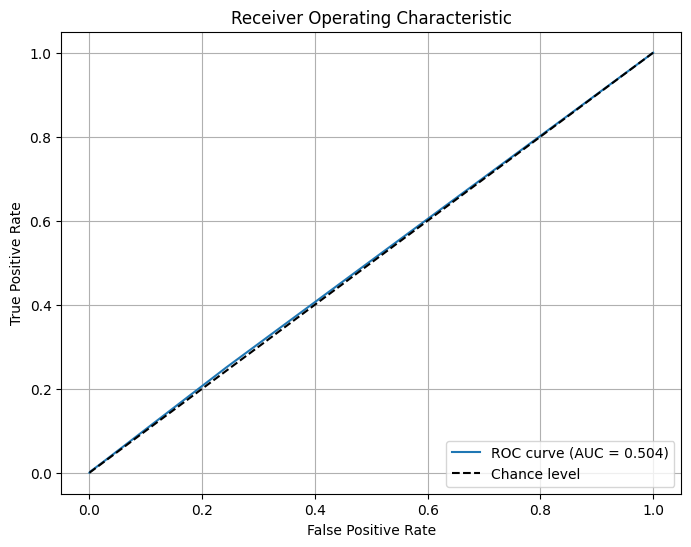

In [ ]:
# Plot ROC curve
from sklearn.metrics import roc_curve, auc
fpr, tpr, _ = roc_curve(y_val_aligned, y_val_proba[:, 1])
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {auc_score:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Chance level')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

## Logistic Regression

In [ ]:
# Keep only rows with matching features (align y and X)
y_train_aligned = y_train_clean.loc[df_train_encoded_clean.index, 'is_exciting'].values

from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(random_state=42)
X_resampled, y_resampled = rus.fit_resample(X_train_scaled, y_train_aligned)

from sklearn.linear_model import LogisticRegression
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_resampled, y_resampled)

# Keep the validation set unchanged
y_val_prob = log_model.predict_proba(X_val_scaled)[:, 1]

# ROC + AUC evaluation
from sklearn.metrics import roc_curve
fpr, tpr, _ = roc_curve(y_val['is_exciting'], y_val_prob)
auc_score = roc_auc_score(y_val['is_exciting'], y_val_prob)
print(f"AUC score (undersampled): {auc_score:.3f}")


AUC score (undersampled): 0.589


AUC score (SMOTE): 0.592


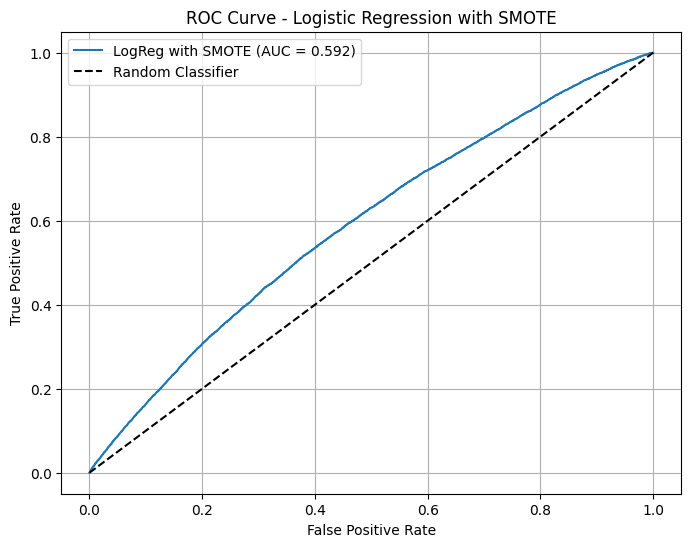

In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# 1. Create a SMOTE instance and apply it to the training data
smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(
    X_train_scaled,
    y_train_sub.loc[df_train_encoded_clean.index, 'is_exciting'].values
)

# 2. Train a logistic regression model on the resampled data
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_smote, y_smote)

# 3. Predict probabilities on the original validation set
y_val_prob = log_model.predict_proba(X_val_scaled)[:, 1]

# 4. Compute ROC curve and AUC score
fpr, tpr, _ = roc_curve(y_val['is_exciting'], y_val_prob)
auc_score = roc_auc_score(y_val['is_exciting'], y_val_prob)

print(f"AUC score (SMOTE): {auc_score:.3f}")

# 5. Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'LogReg with SMOTE (AUC = {auc_score:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression with SMOTE")
plt.legend()
plt.grid(True)
plt.show()


## Random Forest

AUC score (RF + Undersample + Weighted): 0.581

Classification Report:
              precision    recall  f1-score   support

           0      0.892     0.599     0.717     76513
           1      0.160     0.515     0.245     11403

    accuracy                          0.588     87916
   macro avg      0.526     0.557     0.481     87916
weighted avg      0.797     0.588     0.655     87916


Confusion Matrix:
[[45819 30694]
 [ 5535  5868]]


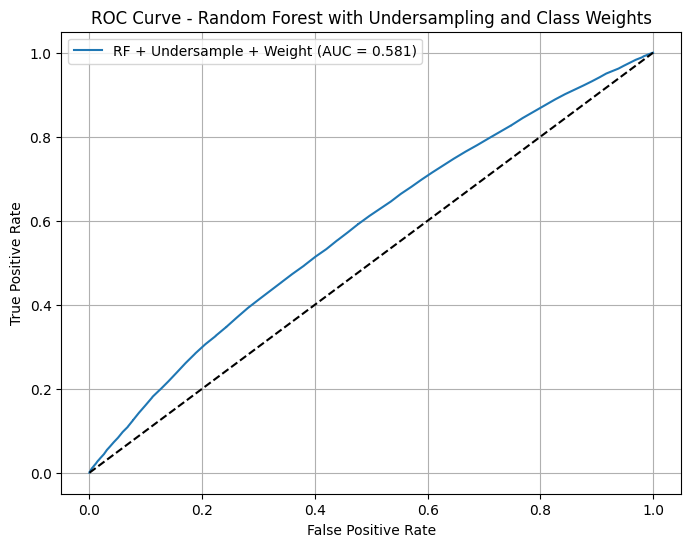

In [ ]:
from imblearn.under_sampling import RandomUnderSampler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, roc_auc_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

# Ensure labels are aligned with the feature set
y_train_clean_array = y_train_clean.values

# Apply random undersampling to the majority class
rus = RandomUnderSampler(random_state=42)
X_rus, y_rus = rus.fit_resample(X_train_scaled, y_train_clean_array)

# Train a Random Forest with class weight adjustment
rf_model_weighted = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42
)
rf_model_weighted.fit(X_rus, y_rus)

# Predict probabilities and labels on the validation set
y_val_prob_weighted = rf_model_weighted.predict_proba(X_val_scaled)[:, 1]
y_val_pred_weighted = rf_model_weighted.predict(X_val_scaled)

# Evaluate performance: ROC curve and AUC
fpr, tpr, _ = roc_curve(y_val['is_exciting'], y_val_prob_weighted)
auc_score_weighted = roc_auc_score(y_val['is_exciting'], y_val_prob_weighted)

print(f"AUC score (RF + Undersample + Weighted): {auc_score_weighted:.3f}")
print("\nClassification Report:")
print(classification_report(y_val['is_exciting'], y_val_pred_weighted, digits=3))
print("\nConfusion Matrix:")
print(confusion_matrix(y_val['is_exciting'], y_val_pred_weighted))

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'RF + Undersample + Weight (AUC = {auc_score_weighted:.3f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest with Undersampling and Class Weights")
plt.legend()
plt.grid(True)
plt.show()


## XGBoost


In [ ]:
!pip install xgboost

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [01:35:57] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


AUC score (XGBoost + Undersampling): 0.565

Classification Report:
              precision    recall  f1-score   support

           0      0.890     0.552     0.681     76513
           1      0.153     0.545     0.239     11403

    accuracy                          0.551     87916
   macro avg      0.522     0.548     0.460     87916
weighted avg      0.795     0.551     0.624     87916


Confusion Matrix:
[[42199 34314]
 [ 5190  6213]]


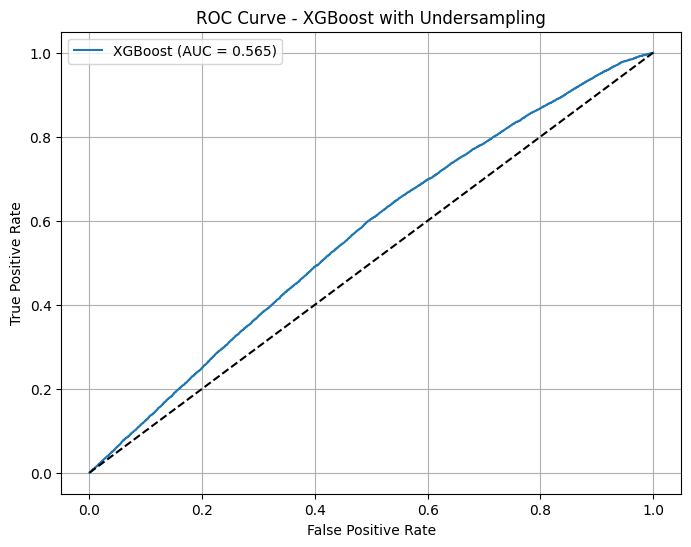

In [ ]:
from imblearn.under_sampling import RandomUnderSampler
from xgboost import XGBClassifier
from sklearn.metrics import roc_curve, roc_auc_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

# 1. Apply random undersampling to balance classes
y_train_clean_array = y_train_clean.values
rus = RandomUnderSampler(random_state=42)
X_rus, y_rus = rus.fit_resample(X_train_scaled, y_train_clean_array)

# 2. Initialize the XGBoost classifier
xgb_model = XGBClassifier(
    n_estimators=100,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

# 3. Train the model on the resampled dataset
xgb_model.fit(X_rus, y_rus)

# 4. Predict probabilities and class labels on the validation set
y_val_prob_xgb = xgb_model.predict_proba(X_val_scaled)[:, 1]
y_val_pred_xgb = xgb_model.predict(X_val_scaled)

# 5. Evaluate the model using ROC curve and classification metrics
fpr, tpr, _ = roc_curve(y_val['is_exciting'], y_val_prob_xgb)
auc_score_xgb = roc_auc_score(y_val['is_exciting'], y_val_prob_xgb)

print(f"AUC score (XGBoost + Undersampling): {auc_score_xgb:.3f}")
print("\nClassification Report:")
print(classification_report(y_val['is_exciting'], y_val_pred_xgb, digits=3))
print("\nConfusion Matrix:")
print(confusion_matrix(y_val['is_exciting'], y_val_pred_xgb))

# 6. Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'XGBoost (AUC = {auc_score_xgb:.3f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XGBoost with Undersampling")
plt.legend()
plt.grid(True)
plt.show()


## SVM

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Classification Report:
              precision    recall  f1-score   support

           0      0.893     0.659     0.759     76513
           1      0.171     0.471     0.251     11403

    accuracy                          0.635     87916
   macro avg      0.532     0.565     0.505     87916
weighted avg      0.799     0.635     0.693     87916


Confusion Matrix:
[[50449 26064]
 [ 6036  5367]]

AUC score (SVM + SMOTE + balanced weights): 0.5937


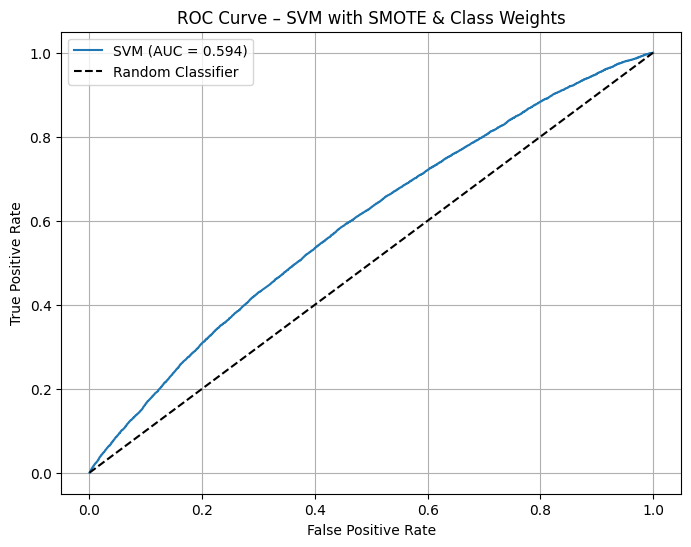

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import roc_curve, roc_auc_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

# 1. Train an SVM with linear kernel, enable probability estimates, and use balanced class weights
svm_model = SVC(
    kernel='linear',
    probability=True,
    class_weight='balanced',
    random_state=42
)
svm_model.fit(X_train_resampled, y_train_resampled)

# 2. Predict probabilities and class labels on the validation set
y_val_prob_svm = svm_model.predict_proba(X_val_scaled)[:, 1]
y_val_pred_svm = svm_model.predict(X_val_scaled)

# 3. Print classification report and confusion matrix
print("Classification Report:")
print(classification_report(y_val, y_val_pred_svm, digits=3))
print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_val_pred_svm))

# 4. Compute ROC curve and AUC score
fpr_svm, tpr_svm, _ = roc_curve(y_val, y_val_prob_svm)
auc_score_svm = roc_auc_score(y_val, y_val_prob_svm)
print(f"\nAUC score (SVM + SMOTE + balanced weights): {auc_score_svm:.4f}")

# 5. Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr_svm, tpr_svm, label=f'SVM (AUC = {auc_score_svm:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – SVM with SMOTE & Class Weights")
plt.legend()
plt.grid(True)
plt.show()